In [ ]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## 1. Imports and Model Loading

In [1]:
import os
import imageio
import uuid
from IPython.display import Image as ImageDisplay
from inference import Inference, ready_gaussian_for_video_rendering, render_video, load_image, load_single_mask, display_image, make_scene, interactive_visualizer

2026-03-26 21:49:28.954 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:17 - GPU name is NVIDIA GeForce RTX 4090
2026-03-26 21:49:29.465 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/jim/git_repo/sam-3d-objects/.pixi/envs/default/lib/python3.11/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/home/jim/git_repo/sam-3d-objects/.pixi/envs/default/lib/python3.11/site-packages/spconv/pytorch/functional.py:96: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/home/jim/git_repo/sam-3d-objects/.pixi/envs/default/lib/python3.11/site-packages/spconv/pytorch/functional.py:162: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/home/jim/git_repo/sam-3d-objects/.pixi/envs/default/lib/python3.11/site-packages/spconv/pytorch/functional.py:242: FutureWarning: 

[SPARSE][CONV] spconv algo: auto


2026-03-26 21:49:31.649 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-26 21:49:31.651 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


In [2]:
PATH = os.getcwd()
TAG = "hf"
config_path = f"{PATH}/../checkpoints/{TAG}/pipeline.yaml"
inference = Inference(config_path, compile=False)

2026-03-26 21:49:34.349 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


/home/jim/git_repo/sam-3d-objects/.pixi/envs/default/lib/python3.11/site-packages/moge/model/v1.py:171: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
2026-03-26 21:49:36.595 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-26 21:49:36.596 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:100 - self.device: cuda
2026-03-26 21:49:36.598 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:101 - CUDA_VISIBLE_DEVICES: None
2026-03-26 21:49:36.599 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:102 - Actually using GPU: 0
2026-03-26 21:49:36.600 | INFO     | sam3d_objects.pipeline.inference_pipeline:init_pose_decoder:297 - Using pose decoder: ScaleShiftInvariant
2026-03-26 21:49:36.601 | INFO     | s

## 2. Load input image to lift to 3D (single object)

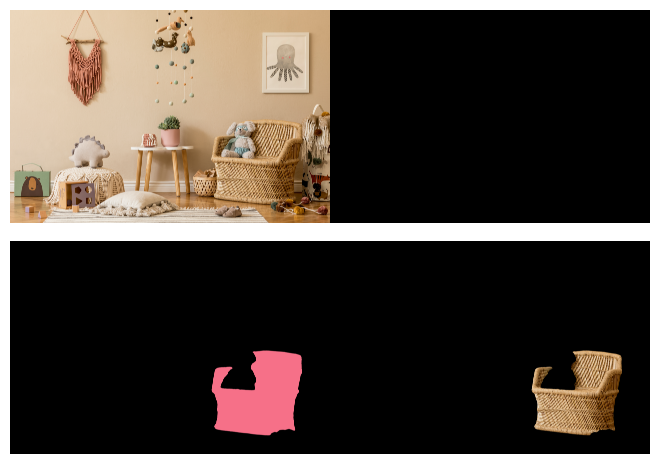

In [15]:
IMAGE_PATH = f"{PATH}/images/shutterstock_stylish_kidsroom_1640806567/image.png"
# IMAGE_PATH = f"{PATH}/images/office/image.png"
IMAGE_NAME = os.path.basename(os.path.dirname(IMAGE_PATH))

image = load_image(IMAGE_PATH)
mask = load_single_mask(os.path.dirname(IMAGE_PATH), index=13)
# mask = load_single_mask(os.path.dirname(IMAGE_PATH), index=0)
display_image(image, masks=[mask])

## 3. Generate Gaussian Splat

In [16]:
# run model
output = inference(image, mask, seed=42)

# export gaussian splat (as point cloud)
# output["gs"].save_ply(f"{PATH}/gaussians/single/{IMAGE_NAME}.ply")

2026-03-26 23:06:38.809 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:664 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-03-26 23:06:38.809 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:633 - Running condition embedder ...
2026-03-26 23:06:38.866 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Condition embedder finishes!
2026-03-26 23:06:42.570 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:714 - Downsampled coords from 34208 to 32446
2026-03-26 23:06:42.573 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:437 - Rescaling scale by 1 after downsampling
2026-03-26 23:06:42.574 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:441 - Finished!


In [17]:
print(output['voxel'].shape)
print(output['shape'].shape)
import torch
torch.save(output, f"{PATH}/gaussians/single/{IMAGE_NAME}.pt")

torch.Size([32446, 3])
torch.Size([1, 4096, 8])


In [21]:
import open3d
import numpy as np
pcd_scene = open3d.geometry.PointCloud()
pcd_scene.points = open3d.utility.Vector3dVector(output["pointmap"].reshape(-1, 3).cpu().numpy())
pcd_scene.colors = open3d.utility.Vector3dVector(output["pointmap_colors"].reshape(-1, 3).cpu().numpy())
object_voxels_canonical = output['voxel']
object_scale = output['scale']
translation = output['translation']
rotation = output['rotation']
print(object_voxels_canonical.shape)

from pytorch3d.transforms import (
    Rotate,
    Translate,
    Scale,
    Transform3d,
    quaternion_to_matrix,
    axis_angle_to_quaternion,
)

def compose_transform(
    scale: torch.Tensor, rotation: torch.Tensor, translation: torch.Tensor
) -> Transform3d:
    """
    Args:
        scale: (..., 3) tensor of scale factors
        rotation: (..., 3, 3) tensor of rotation matrices
        translation: (..., 3) tensor of translation vectors
    """
    tfm = Transform3d(dtype=scale.dtype, device=scale.device)
    return tfm.scale(scale).rotate(rotation).translate(translation)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
Rotation = quaternion_to_matrix(rotation.squeeze(1))
center = translation[0].clone()
tfm_ori = compose_transform(scale=object_scale, rotation=Rotation, translation=translation)
print(tfm_ori.get_matrix())

# rotate mesh (from z-up to y-up)
# object_pcd_metric = object_voxels_canonical.cpu().numpy() @ np.array([[1, 0, 0], [0, 0, -1], [0, 1, 0]]).T
object_pcd_metric = object_voxels_canonical.cpu().numpy()
object_pcd_metric = torch.from_numpy(object_pcd_metric).float().to(device)
object_pcd_metric = tfm_ori.transform_points(object_pcd_metric.unsqueeze(0))
object_pcd_metric = object_pcd_metric[0].cpu().numpy()  # pytorch3d, y-up, x left, z inwards.
pcd_object = open3d.geometry.PointCloud()
pcd_object.points = open3d.utility.Vector3dVector(object_pcd_metric)

# Initialize the WebRTC server for Jupyter
open3d.visualization.webrtc_server.enable_webrtc()

# Draw using the new non-blocking web visualizer
open3d.web_visualizer.draw([pcd_scene, pcd_object])

# open3d.visualization.draw_geometries([pcd_scene, pcd_object])
# open3d.visualization.draw_plotly([pcd_scene, pcd_object])

torch.Size([32446, 3])
tensor([[[-0.3609,  0.0274, -0.2811,  0.0000],
         [-0.2823, -0.0483,  0.3578,  0.0000],
         [-0.0082,  0.4549,  0.0549,  0.0000],
         [-0.4380, -0.2099,  1.7864,  1.0000]]], device='cuda:0')
[Open3D INFO] WebRTC GUI backend enabled.


RuntimeError: [1;31m[Open3D Error] (void open3d::visualization::gui::Application::SetWindowSystem(std::shared_ptr<open3d::visualization::gui::WindowSystem>)) /root/Open3D/cpp/open3d/visualization/gui/Application.cpp:346: Cannot set WindowSystem. It is already set.
[0;m

## 4. Visualize Gaussian Splat
### a. Animated Gif

In [ ]:
# render gaussian splat
scene_gs = make_scene(output)
scene_gs = ready_gaussian_for_video_rendering(scene_gs)

video = render_video(
    scene_gs,
    r=1,
    fov=60,
    pitch_deg=15,
    yaw_start_deg=-45,
    resolution=512,
)["color"]

# save video as gif
imageio.mimsave(
    os.path.join(f"{PATH}/gaussians/single/{IMAGE_NAME}.gif"),
    video,
    format="GIF",
    duration=1000 / 30,  # default assuming 30fps from the input MP4
    loop=0,  # 0 means loop indefinitely
)

# notebook display
ImageDisplay(url=f"gaussians/single/{IMAGE_NAME}.gif?cache_invalidator={uuid.uuid4()}")

### b. Interactive Visualizer

In [ ]:
# might take a while to load (black screen)
interactive_visualizer(f"{PATH}/gaussians/single/{IMAGE_NAME}.ply")